In [1]:
import pandas as pd
import numpy as np
import toolkit
import pickle as pkl

In [2]:
with open("data/train.pkl", "rb") as file:
    train = pkl.load(file)

In [3]:
with open("data/test.pkl", "rb") as file:
    test = pkl.load(file)

In [4]:
train.shape, test.shape

((17416, 2), (1936, 2))

In [5]:
train.head()

,Status,Message
973,2,From OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM...
4592,0,Return-Path: skip@pobox.com\n.Delivery-Date: S...
13730,0,From ilug-admin@linux.ie Fri Jul 19 23:44:22 ...
3046,2,From travelincentives@aol.com Mon Aug 6 20:0...
6790,0,From rpm-list-admin@freshrpms.net Wed Jul 31 ...


In [6]:
test.head()

,Status,Message
10667,0,From rpm-list-admin@freshrpms.net Fri Jul 26 ...
9651,0,From ilug-admin@linux.ie Tue Jul 30 10:11:31 ...
7830,0,From fork-admin@xent.com Tue Oct 1 10:41:44 ...
6459,0,From fork-admin@xent.com Thu Jul 25 11:08:06 ...
2399,2,Received: from hq.pro-ns.net (localhost [127.0...


In [7]:
train = toolkit.introductory_pipeline(train)
test = toolkit.introductory_pipeline(test)

In [8]:
train.head()

,by,.,with,2002,the,of,-0500,to,I,a,...,email,Microsoft,its,>,our,want,<a,.<font,Status,domain
0,5,86,8,7,4,4,2,11,0,6,...,2,0,0,0,1,0,6,3,2,unimportant
1,0,4,3,2,2,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,pobox.com
2,5,18,6,10,9,6,0,9,6,10,...,0,0,0,0,0,0,0,0,0,linux.ie
3,2,12,1,0,6,3,0,3,0,1,...,0,2,0,0,0,0,0,0,2,aol.com
4,4,15,5,9,2,1,0,3,0,0,...,0,0,0,0,0,0,0,0,0,freshrpms.net


In [9]:
test.head()

,by,.,with,2002,the,of,-0500,to,I,a,...,email,Microsoft,its,>,our,want,<a,.<font,Status,domain
0,5,22,6,10,1,2,0,4,1,1,...,0,0,0,0,0,0,0,0,0,freshrpms.net
1,6,29,6,10,0,0,0,2,0,2,...,0,0,0,0,0,0,0,0,0,linux.ie
2,5,17,9,10,11,6,1,11,3,9,...,0,0,0,8,0,0,0,0,0,xent.com
3,8,34,10,11,13,9,0,14,13,8,...,9,0,0,1,0,0,0,0,0,xent.com
4,2,42,8,12,3,3,6,4,0,0,...,2,0,0,0,0,0,0,0,2,unknown


In [21]:
with open("data/preprocessed_trainig.pkl", "wb") as file:
    pkl.dump(train, file)
with open("data/preprocessed_test.pkl", "wb") as file:
    pkl.dump(test, file)

In [11]:
len(train["domain"].unique())

24

In [12]:
train["domain"].isna().mean()

np.float64(0.0)

In [13]:
test["domain"].value_counts()

domain
xent.com                    437
unimportant                 306
jmason.org                  217
linux.ie                    199
lists.sourceforge.net       173
freshrpms.net               158
unknown                     149
redhat.com                   96
hotmail.com                  39
returns.groups.yahoo.com     30
yahoo.com                    25
perl.org                     22
petting-zoo.net              13
aol.com                      13
taint.org                    10
msn.com                      10
insurancemail.net             8
insiq.us                      7
securityfocus.com             5
btamail.net.cn                5
python.org                    4
pobox.com                     4
eudoramail.com                3
comcast.net                   3
Name: count, dtype: int64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
counted = train.groupby(["domain", "Status"]).size().reset_index(name="count")

In [16]:
counted = counted.merge(train.groupby(["domain"]).size().reset_index(name="sum"), how="left", on="domain")

In [17]:
counted["count"] = counted["count"] / counted["sum"]

In [18]:
counted

,domain,Status,count,sum
0,aol.com,2,1.000000,120
1,btamail.net.cn,2,1.000000,60
2,comcast.net,0,1.000000,65
3,eudoramail.com,2,1.000000,55
4,freshrpms.net,0,0.995402,1305
5,freshrpms.net,1,0.004598,1305
6,hotmail.com,0,0.032362,309
7,hotmail.com,2,0.967638,309
8,insiq.us,2,1.000000,76
9,insurancemail.net,2,1.000000,100


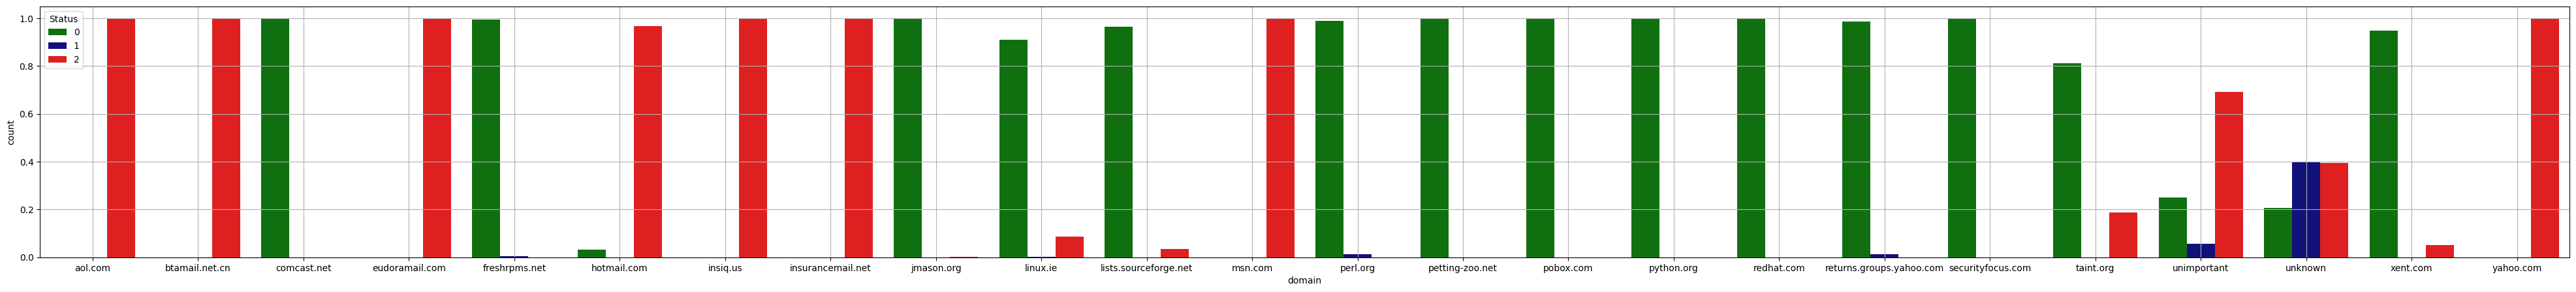

In [19]:
plt.figure(figsize=(50, 5))
sns.barplot(data=counted, x="domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()